In [17]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import math
import glob
import re
sns.set(style='whitegrid')

In [18]:
wid_exp_depth = [(512, 16, 16), (512, 32, 12), (512, 64, 8),]
lrs = [0.004, 0.006, 0.008, 0.012, 0.016]
seeds = [1]

time = '20251026_035820'

In [19]:
results_val = {}
results_tr = {}
for lr in lrs:
    for width, num_exp, depth in wid_exp_depth:
            num_act = int(num_exp // 4)
            for seed in seeds:
                print()
                file_name = f'../run_data/mutransfer_lr_fineweb/out_{time}/width{width}_depth{depth}_experts{num_exp}_active{num_act}_seed{seed}_lr{lr}_alpha1.0_mult0.5/log.csv'
                if os.path.exists(file_name):
                    try:
                        csv_df = pd.read_csv(file_name)
                    except:
                        print(f"File {file_name} is corrupted, skipping")
                        results_val[(width, num_exp, num_act, seed, lr)] = 10.0
                        results_tr[(width, num_exp, num_act, seed, lr)] = 10.0
                        continue
                    val_loss = csv_df.iloc[-1]['val/loss']
                    if val_loss > 0.0:
                        avg_train_loss = np.mean(csv_df['train/loss'][-50:])
                        print(f"result found for {file_name}, val_loss achieved {val_loss}")
                        print(f"average training loss for last 50 steps: {avg_train_loss}")
                        results_val[(width, num_exp, num_act, depth, seed, lr)] = val_loss
                        results_tr[(width, num_exp, num_act, depth, seed, lr)] = avg_train_loss
                    else:
                        print(f"No validation loss found for {file_name}, trial ended at iteration {csv_df.shape[0]}")
                        print(f"Lowest traininig loss achieved: {np.min(csv_df['train/loss'])}")
                else:
                    print(f"File {file_name} does not exist, check your path")


result found for ../run_data/mutransfer_lr_fineweb/out_20251026_035820/width512_depth16_experts16_active4_seed1_lr0.004_alpha1.0_mult0.5/log.csv, val_loss achieved 3.4355039596557617
average training loss for last 50 steps: 3.433558702468872

result found for ../run_data/mutransfer_lr_fineweb/out_20251026_035820/width512_depth12_experts32_active8_seed1_lr0.004_alpha1.0_mult0.5/log.csv, val_loss achieved 3.4142725467681885
average training loss for last 50 steps: 3.412271022796631

File ../run_data/mutransfer_lr_fineweb/out_20251026_035820/width512_depth8_experts64_active16_seed1_lr0.004_alpha1.0_mult0.5/log.csv does not exist, check your path

result found for ../run_data/mutransfer_lr_fineweb/out_20251026_035820/width512_depth16_experts16_active4_seed1_lr0.006_alpha1.0_mult0.5/log.csv, val_loss achieved 3.4335765838623047
average training loss for last 50 steps: 3.431650161743164

result found for ../run_data/mutransfer_lr_fineweb/out_20251026_035820/width512_depth12_experts32_active

In [20]:
wid_exp_depth = [(512, 24, 8), (512, 24, 16), (512, 24, 32),]
lrs = [0.004, 0.006, 0.008, 0.012, 0.016]
seeds = [1]
time = '20251026_043120'

for lr in lrs:
    for width, num_exp, depth in wid_exp_depth:
            num_act = int(num_exp // 4)
            for seed in seeds:
                print()
                file_name = f'../run_data/mutransfer_lr_fineweb/out_{time}/width{width}_depth{depth}_experts{num_exp}_active{num_act}_seed{seed}_lr{lr}_alpha1.0_mult0.5_depth{depth}/log.csv'
                if os.path.exists(file_name):
                    try:
                        csv_df = pd.read_csv(file_name)
                    except:
                        print(f"File {file_name} is corrupted, skipping")
                        results_val[(width, num_exp, num_act, seed, lr)] = 10.0
                        results_tr[(width, num_exp, num_act, seed, lr)] = 10.0
                        continue
                    val_loss = csv_df.iloc[-1]['val/loss']
                    if val_loss > 0.0:
                        avg_train_loss = np.mean(csv_df['train/loss'][-50:])
                        print(f"result found for {file_name}, val_loss achieved {val_loss}")
                        print(f"average training loss for last 50 steps: {avg_train_loss}")
                        results_val[(width, num_exp, num_act, depth, seed, lr)] = val_loss
                        results_tr[(width, num_exp, num_act, depth, seed, lr)] = avg_train_loss
                    else:
                        print(f"No validation loss found for {file_name}, trial ended at iteration {csv_df.shape[0]}")
                        print(f"Lowest traininig loss achieved: {np.min(csv_df['train/loss'])}")
                else:
                    print(f"File {file_name} does not exist, check your path")


result found for ../run_data/mutransfer_lr_fineweb/out_20251026_043120/width512_depth8_experts24_active6_seed1_lr0.004_alpha1.0_mult0.5_depth8/log.csv, val_loss achieved 3.504891395568848
average training loss for last 50 steps: 3.5029561519622803

result found for ../run_data/mutransfer_lr_fineweb/out_20251026_043120/width512_depth16_experts24_active6_seed1_lr0.004_alpha1.0_mult0.5_depth16/log.csv, val_loss achieved 3.3866443634033203
average training loss for last 50 steps: 3.3846242427825928

File ../run_data/mutransfer_lr_fineweb/out_20251026_043120/width512_depth32_experts24_active6_seed1_lr0.004_alpha1.0_mult0.5_depth32/log.csv does not exist, check your path

result found for ../run_data/mutransfer_lr_fineweb/out_20251026_043120/width512_depth8_experts24_active6_seed1_lr0.006_alpha1.0_mult0.5_depth8/log.csv, val_loss achieved 3.5053470134735107
average training loss for last 50 steps: 3.503485679626465

result found for ../run_data/mutransfer_lr_fineweb/out_20251026_043120/widt

In [21]:
def plot_results(result, title = ""):
    plt.figure(figsize=(10, 6))
    config_results = {}
    for (width, num_exp, num_act, depth, seed, lr), mse in result.items():
        config = (num_exp, width, depth)
        if config not in config_results:
            config_results[config] = []
        config_results[config].append((lr, mse))
    
    # Average over seeds for each configuration and lr
    averaged_results = {}
    for config, pts in config_results.items():
        lr_to_mses = {}
        for lr, mse in pts:
            if lr not in lr_to_mses:
                lr_to_mses[lr] = []
            lr_to_mses[lr].append(mse)
        
        # Average MSEs for each lr
        averaged_pts = []
        for lr in sorted(lr_to_mses.keys()):
            avg_mse = np.mean(lr_to_mses[lr])
            averaged_pts.append((lr, avg_mse))
        averaged_results[config] = averaged_pts
    
    # Count total experiments
    total_experiments = len(result)
    print(f"Total experiments: {total_experiments}")
    
    # Print summary
    print("\nResults by configuration:")
    for (n_exp, width, depth), pts in sorted(averaged_results.items()):
        valid_pts = [(lr, mse) for lr, mse in pts if not math.isnan(mse)]
        print(f"  n={n_exp}, width={width}, depth={depth}: {len(valid_pts)} valid lr points")
        if valid_pts:
            best_lr, best_mse = min(valid_pts, key=lambda x: x[1])
            print(f"    Best: lr={best_lr:.3e}, MSE={best_mse:.6f}")
    
    # Plot each configuration
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h']
    
    for idx, ((n_exp, width, depth), pts) in enumerate(sorted(averaged_results.items())):
        if pts:
            # Sort by lr for proper line plotting
            pts_sorted = sorted(pts, key=lambda t: t[0])
            lrs_plot, mses = zip(*pts_sorted)
            
            # Filter out NaN values
            valid_pts = [(lr, mse) for lr, mse in zip(lrs_plot, mses) if not math.isnan(mse)]
            
            if valid_pts:
                valid_lrs, valid_mses = zip(*valid_pts)
                color = colors[idx % len(colors)]
                marker = markers[idx % len(markers)]
                num_act = int(n_exp // 4)
                plt.plot(valid_lrs, valid_mses, marker=marker, color=color,
                        label=f'n_exp={n_exp}, n_act={num_act}, width={width}, depth={depth}', linewidth=1.5, markersize=6,
                        alpha=0.8)
                
                # Mark the best point with a star
                best_idx = np.argmin(valid_mses)
                plt.scatter(valid_lrs[best_idx], valid_mses[best_idx], 
                           s=200, color=color, marker='*', edgecolor='black', 
                           linewidth=2, zorder=10)

    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.ylim(3.3, 3.8)
    plt.xlabel(r'Learning rate', fontsize=12)
    plt.ylabel('log perplexity', fontsize=12)
    plt.title(f'Hyperparameter Transfer Results (no router learning) ' + title, 
              fontsize=14)
    plt.legend(fontsize=10, loc='best', ncol=2)
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    
    # Save plot
    plot_dir = "plots"
    os.makedirs(plot_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_name = os.path.join(plot_dir, f"hp_transfer_plot_{timestamp}.png")
    plt.savefig(plot_name, dpi=150, bbox_inches='tight')
    print(f"\nPlot saved as: {plot_name}")
    
    plt.show()
    
    return averaged_results


def parse_validation_loss(log_file_path):
    result = {}
    pattern = r'Validation - step (\d+): val loss ([\d.]+)'

    try:
        with open(log_file_path, 'r') as f:
            for line in f:
                match = re.search(pattern, line)
                if match:
                    step = int(match.group(1))
                    loss = float(match.group(2))
                    result[step] = loss
    except FileNotFoundError:
        print(f"Error: File {log_file_path} not found")
        return {}
    except Exception as e:
        print(f"Error reading file: {e}")
        return {}

    return result

def find_job_file(base_path, time_dir, job_prefix):

    # Construct the search path
    search_pattern = os.path.join(base_path, time_dir, "stdout", f"{job_prefix}_*.log")

    # Find matching files
    matches = glob.glob(search_pattern)

    if not matches:
        return None, None

    # Take the first match if multiple exist
    full_path = matches[0]
    filename = os.path.basename(full_path)

    # Parse filename: job_0008_gpu7_w256_exp4_lr4.52e-02_seed0.log
    pattern = r'job_\d+_gpu\d+_w(\d+)_exp(\d+)_lr([\d.e\-+]+)_seed(\d+)\.log'
    match = re.match(pattern, filename)

    if not match:
        return filename, None

    params = {
        'width': int(match.group(1)),
        'num_exp': int(match.group(2)),
        'lr': float(match.group(3)),
        'seed': int(match.group(4))
    }

    return filename, params

Total experiments: 18

Results by configuration:
  n=16, width=512, depth=16: 5 valid lr points
    Best: lr=8.000e-03, MSE=3.429645
  n=24, width=512, depth=8: 5 valid lr points
    Best: lr=1.600e-02, MSE=3.457256
  n=24, width=512, depth=16: 5 valid lr points
    Best: lr=4.000e-03, MSE=3.386644
  n=32, width=512, depth=12: 3 valid lr points
    Best: lr=6.000e-03, MSE=3.399620



Plot saved as: plots/hp_transfer_plot_20251026_193747.png


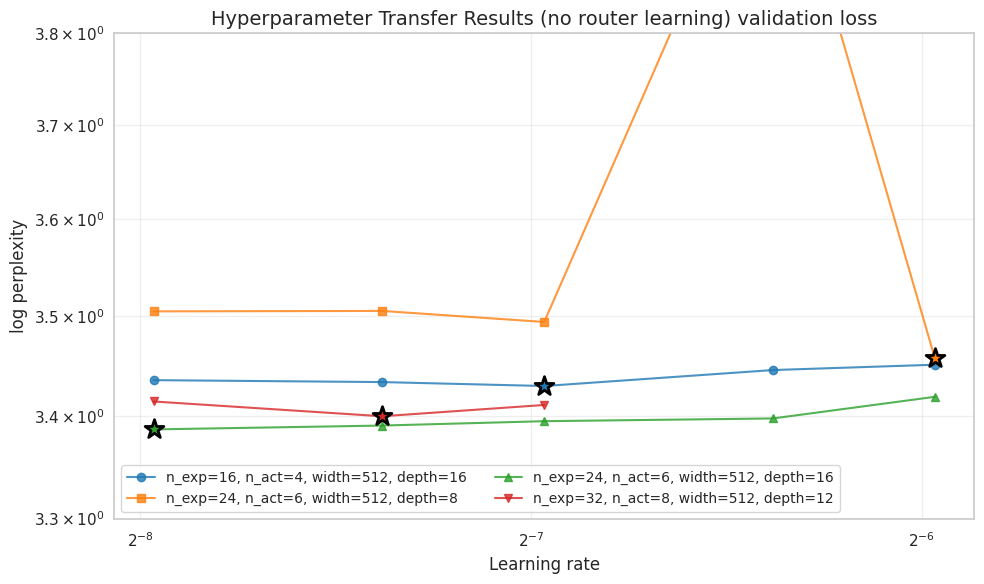

{(16, 512, 16): [(0.004, np.float64(3.4355039596557617)),
  (0.006, np.float64(3.4335765838623047)),
  (0.008, np.float64(3.429645299911499)),
  (0.012, np.float64(3.4455933570861816)),
  (0.016, np.float64(3.4509477615356445))],
 (32, 512, 12): [(0.004, np.float64(3.4142725467681885)),
  (0.006, np.float64(3.399620056152344)),
  (0.008, np.float64(3.4107940196990967))],
 (24, 512, 8): [(0.004, np.float64(3.504891395568848)),
  (0.006, np.float64(3.5053470134735107)),
  (0.008, np.float64(3.494116306304932)),
  (0.012, np.float64(4.06724214553833)),
  (0.016, np.float64(3.4572558403015137))],
 (24, 512, 16): [(0.004, np.float64(3.3866443634033203)),
  (0.006, np.float64(3.3904452323913574)),
  (0.008, np.float64(3.394745111465454)),
  (0.012, np.float64(3.397454023361206)),
  (0.016, np.float64(3.4189019203186035))]}

In [22]:
plot_results(results_val, title = "validation loss")

In [23]:
results_val

{(512, 16, 4, 16, 1, 0.004): np.float64(3.4355039596557617),
 (512, 32, 8, 12, 1, 0.004): np.float64(3.4142725467681885),
 (512, 16, 4, 16, 1, 0.006): np.float64(3.4335765838623047),
 (512, 32, 8, 12, 1, 0.006): np.float64(3.399620056152344),
 (512, 16, 4, 16, 1, 0.008): np.float64(3.429645299911499),
 (512, 32, 8, 12, 1, 0.008): np.float64(3.4107940196990967),
 (512, 16, 4, 16, 1, 0.012): np.float64(3.4455933570861816),
 (512, 16, 4, 16, 1, 0.016): np.float64(3.4509477615356445),
 (512, 24, 6, 8, 1, 0.004): np.float64(3.504891395568848),
 (512, 24, 6, 16, 1, 0.004): np.float64(3.3866443634033203),
 (512, 24, 6, 8, 1, 0.006): np.float64(3.5053470134735107),
 (512, 24, 6, 16, 1, 0.006): np.float64(3.3904452323913574),
 (512, 24, 6, 8, 1, 0.008): np.float64(3.494116306304932),
 (512, 24, 6, 16, 1, 0.008): np.float64(3.394745111465454),
 (512, 24, 6, 8, 1, 0.012): np.float64(4.06724214553833),
 (512, 24, 6, 16, 1, 0.012): np.float64(3.397454023361206),
 (512, 24, 6, 8, 1, 0.016): np.float